# Umbralizacion
### Tecnica de isodata

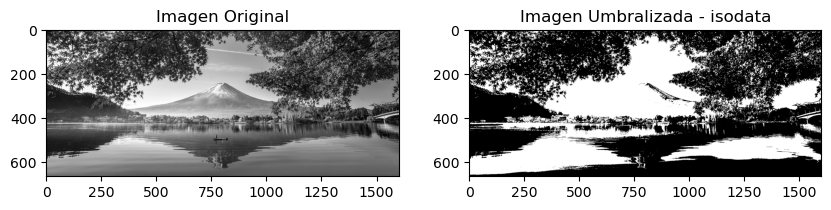

Umbral: 116.39561708421037


True

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata(imagen):
  # Varia dependiendo del umbral inicial
  umbral = 128
  while True:
    # Separa la imagen en dos grupos
    grupo1 = imagen[imagen <= umbral]
    grupo2 = imagen[imagen >= umbral]

    # Calcula el promedio de cada grupo
    media1 = np.mean(grupo1) if len(grupo1) > 0 else 0
    media2 = np.mean(grupo2) if len(grupo2) > 0 else 0

    # Calcula el nuevo umbral
    nuevo_umbral = (media1 + media2) / 2

    # Si el umbral no cambia, termina el bucle
    if abs(nuevo_umbral - umbral) < 1:
      break

    umbral = nuevo_umbral
  
  return umbral

# leer imagen en escala de grises, canal 0
imagen = cv2.imread('./images/1.jpeg', 0)

umbral_isodata = isodata(imagen)

# _, imagen_isodata = cv2.threshold(imagen, umbral_isodata, 255, cv2.THRESH_BINARY_INV) # Para elminar fondos blancos
_, imagen_isodata = cv2.threshold(imagen, umbral_isodata, 255, cv2.THRESH_BINARY) # Para eliminar fondos negros

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Imagen Umbralizada - isodata')
plt.imshow(imagen_isodata, cmap='gray')
plt.show()

print(f'Umbral: {umbral_isodata}')
cv2.imwrite('./results/isodata_1.png', imagen_isodata)


### Tecnica de dos picos

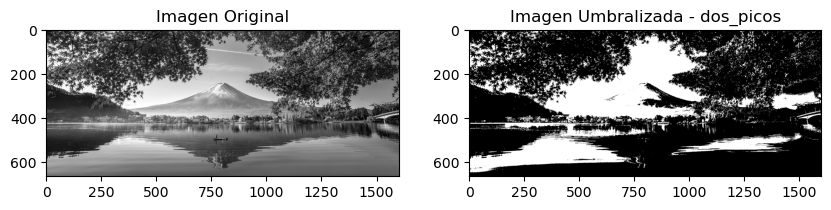

Umbral: 138


True

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(imagen):
  # Histograma de la imagen
  histograma = cv2.calcHist([imagen], [0], None, [256], [0, 256])
  
  # Encuentra los picos en el histograma
  pico = np.array(histograma).flatten() # flatten para convertir a 1 Dimension
  pico_dif = np.diff(pico)
  
  primer_pico = np.argmax(pico_dif[:128])
  segundo_pico = np.argmax(pico_dif[128:]) + 128
  
  umbral_dos_picos = int((primer_pico + segundo_pico) / 2)
  return umbral_dos_picos

image = cv2.imread('./images/1.jpeg', 0)
umbral_dos_picos = dos_picos(image)

_, imagen_dos_picos = cv2.threshold(image, umbral_dos_picos, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Imagen Umbralizada - dos_picos')
plt.imshow(imagen_dos_picos, cmap='gray')
plt.show()

print(f'Umbral: {umbral_dos_picos}')
cv2.imwrite('./results/dos_picos_1.png', imagen_dos_picos)


### Metodo de otsu

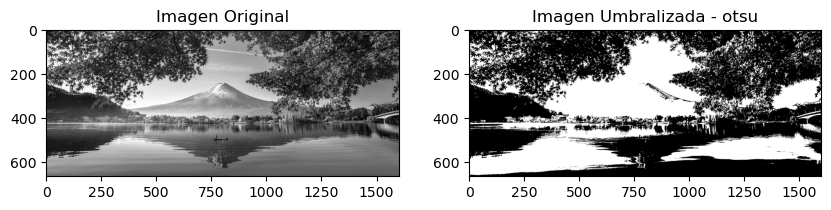

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./images/1.jpeg', 0)
_, imagen_otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

umbral_imagen = np.where(image > imagen_otsu, 255, 0).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Imagen Umbralizada - otsu')
plt.imshow(imagen_otsu, cmap='gray')
plt.show()


/var/folders/p5/9q_ff1ts34z4t_mrnn9362xh0000gn/T/ipykernel_49189/785333774.py:70: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.flatten(), 256, [0, 256], color='gray')


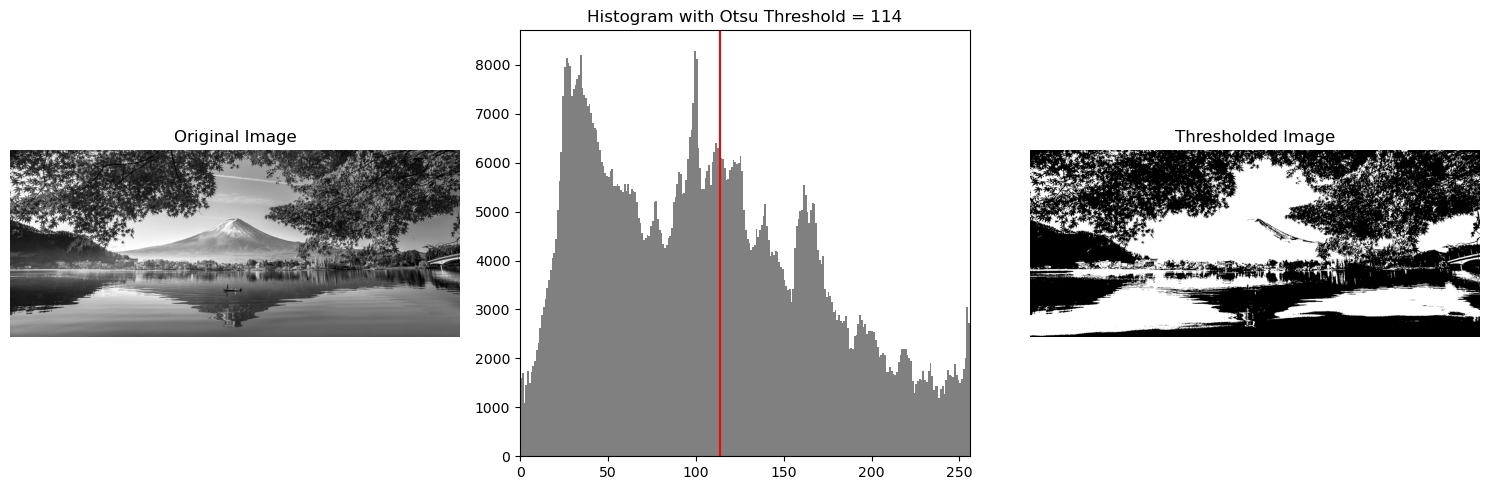

In [27]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def otsu_threshold(image):
    # Calculate histogram
    hist, bins = np.histogram(image.flatten(), bins=256, range=[0, 256])
    
    # Total number of pixels
    total_pixels = image.size
    
    # Initialize variables
    sum_total = 0
    for i in range(256):
        sum_total += i * hist[i]
    
    # Variables for background and foreground weights and means
    weight_bg = 0
    weight_fg = 0
    sum_bg = 0
    
    max_variance = 0
    threshold = 0
    
    # Iterate through all possible threshold values
    for t in range(256):
        # Update weights
        weight_bg += hist[t]
        if weight_bg == 0:
            continue
            
        weight_fg = total_pixels - weight_bg
        if weight_fg == 0:
            break
            
        # Update means
        sum_bg += t * hist[t]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg
        
        # Calculate between-class variance
        variance = weight_bg * weight_fg * (mean_bg - mean_fg)**2
        
        # Update threshold if variance is greater
        if variance > max_variance:
            max_variance = variance
            threshold = t
    
    return threshold

# Load image in grayscale
image = cv2.imread('./images/1.jpeg', 0)

# Apply our manual Otsu thresholding
otsu_value = otsu_threshold(image)
_, binary_image = cv2.threshold(image, otsu_value, 255, cv2.THRESH_BINARY)

# Display results
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

# Histogram with threshold marked
plt.subplot(1, 3, 2)
plt.title(f'Histogram with Otsu Threshold = {otsu_value}')
plt.hist(image.flatten(), 256, [0, 256], color='gray')
plt.axvline(otsu_value, color='red')
plt.xlim([0, 256])

# Binary image
plt.subplot(1, 3, 3)
plt.title('Thresholded Image')
plt.imshow(binary_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# Umbralizacion variable
### Particion de una imagen

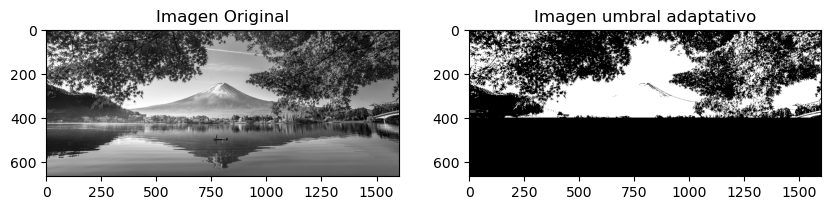

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def variable_umb_bloque(image, tam_bloque, c):
  umbral_img = np.zeros_like(image)
  for y in range(0, image.shape[0], tam_bloque):
    for x in range(0, image.shape[1], tam_bloque):
      bloque = image[y:y+tam_bloque, x:x+tam_bloque]
      bloque_media = np.mean(bloque)
      umbral_adap = bloque_media - c
      umbral_img[y:y+tam_bloque, x:x+tam_bloque] = (bloque > umbral_adap) * 255
    return umbral_img

image = cv2.imread('./images/1.jpeg', 0)

# tam_bloque y c, las tenemos que elegir
umbral_img_adap = variable_umb_bloque(image, 400, 10)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Imagen umbral adaptativo')
plt.imshow(umbral_img_adap, cmap='gray')
plt.show()
  

### Con desviacion

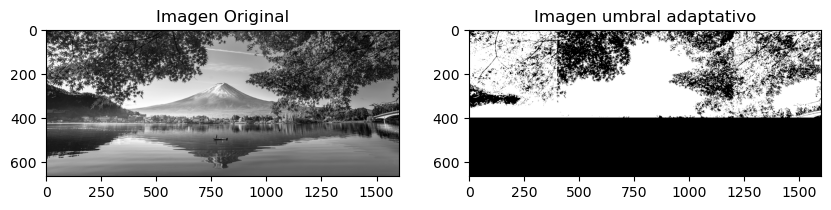

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def umbral_var2(image, tam_bloque, ajuste):
  umbral_img = np.zeros_like(image)
  for y in range(0, image.shape[0], tam_bloque):
    for x in range(0, image.shape[1], tam_bloque):
      bloque = image[y:y+tam_bloque, x:x+tam_bloque]
      bloque_media = np.mean(bloque)
      desv = np.std(bloque)
      umbral_adap = bloque_media - ajuste * desv
      umbral_img[y:y+tam_bloque, x:x+tam_bloque] = (bloque > umbral_adap) * 255
    return umbral_img

image = cv2.imread('./images/1.jpeg', 0)

# tam_bloque y c, las tenemos que elegir
umbral_img = umbral_var2(image, 400, 0.8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Imagen umbral adaptativo')
plt.imshow(umbral_img, cmap='gray')
plt.show()


### Adaptativa con ventana

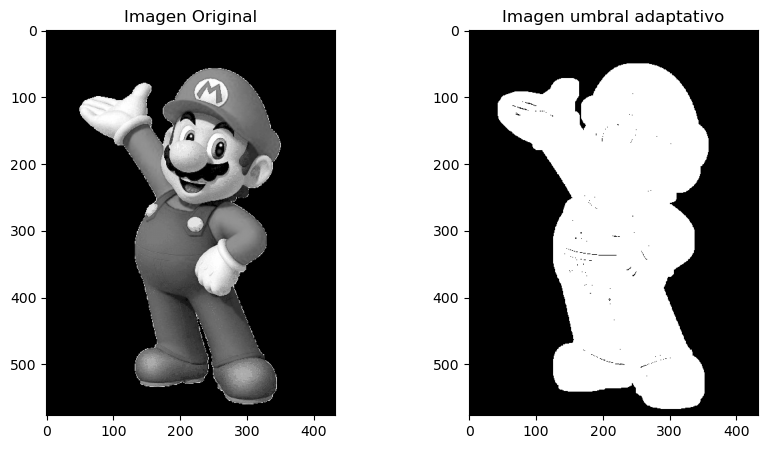

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ventana(image, ventana, factor):
  umbral_img = np.zeros_like(image)
  pad = ventana // 2
  pad_img = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
  for y in range(image.shape[0]):
    for x in range(image.shape[1]):
      ventana1 = pad_img[y:y+ventana, x:x+ventana]
      media = np.mean(ventana1)
      dis = np.std(ventana1)
      umbral = media - factor * dis
      umbral_img[y, x] = 255 if image[y, x] > umbral else 0
  return umbral_img

image = cv2.imread('./images/2.png', 0)

# ventana tiene que ser impar
v = 15
c = 2
umbral_img = ventana(image, v, c)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Imagen umbral adaptativo')
plt.imshow(umbral_img, cmap='gray')
plt.show()


### asdf

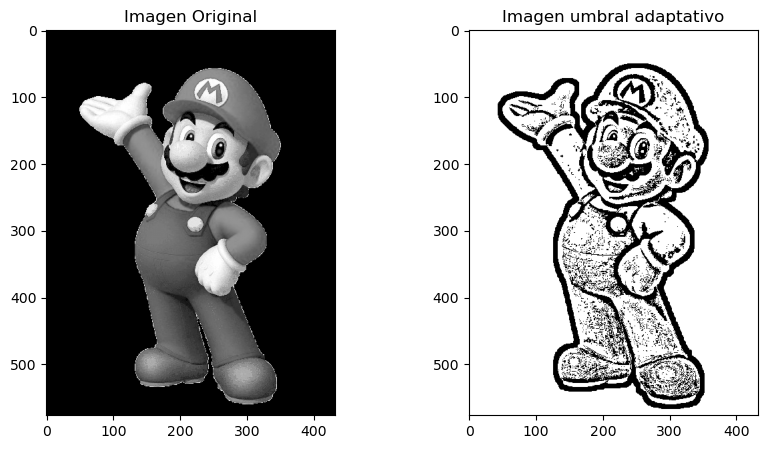

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./images/2.png', 0)
v = 15
factor = 2

imagen_umbr = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, v, factor)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Imagen umbral adaptativo')
plt.imshow(imagen_umbr, cmap='gray')
plt.show()